# 🌾 Model Prediksi Harga Pangan Indonesia
### Berbasis Facebook Prophet — AI Impact Challenge Hackathon

**Sumber data:** PIHPS Bank Indonesia (`bi.go.id/hargapangan`)  
**Komoditas:** Beras Medium I · Minyak Goreng Curah · Cabai Merah Keriting  
**Cakupan:** 33 Provinsi · Januari–April 2026  
**Output:** Prediksi harga 7 hari & 30 hari ke depan per provinsi

---


## 0. Install & Import

In [1]:
# Jalankan sekali saja jika belum terinstall

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import logging
import json
from pathlib import Path
from prophet import Prophet

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

print("✅ Semua library berhasil diimport")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


✅ Semua library berhasil diimport
   pandas  : 3.0.2
   numpy   : 2.1.1


## 1. Konfigurasi Path & Parameter

In [ ]:
# ── Path ──────────────────────────────────────────────────────────
BASE_DIR   = Path(".")          # Sesuaikan jika perlu
CLEAN_DIR  = BASE_DIR / "data" / "dataset" / "clean_dataset"
PRED_DIR   = BASE_DIR / "data" / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

# ── Parameter Model ───────────────────────────────────────────────
HORIZON_HARI          = 30     # Prediksi seberapa jauh ke depan
CHANGEPOINT_SCALE     = 0.05   # Konservatif → hindari overfitting tren pendek
INTERVAL_WIDTH        = 0.80   # 80% confidence interval
FLOOR_RATIO           = 0.40   # Floor = 40% rata-rata historis (cegah prediksi negatif)

# ── Komoditas yang akan dimodelkan ────────────────────────────────
KOMODITAS_LIST = [
    "Beras Medium I",
    "Minyak Goreng Curah",
    "Cabai Merah Keriting",
]

# ── Hari libur nasional 2026 (berpengaruh ke harga pangan) ────────
HARI_LIBUR = pd.DataFrame({
    'holiday': [
        'Tahun Baru', 'Isra Miraj', 'Imlek',
        'Idul Fitri H-1', 'Idul Fitri', 'Idul Fitri H+1',    # Lebaran — paling krusial
        'Idul Fitri H+2', 'Idul Fitri H+3',
        'Waisak', 'Kenaikan Isa', 'HUT RI',
        'Idul Adha', 'Maulid Nabi', 'Natal',
    ],
    'ds': pd.to_datetime([
        '2026-01-01', '2026-01-27', '2026-01-29',
        '2026-03-19', '2026-03-20', '2026-03-21',
        '2026-03-22', '2026-03-23',
        '2026-05-12', '2026-05-14', '2026-08-17',
        '2026-06-17', '2026-09-05', '2026-12-25',
    ]),
    'lower_window': 0,
    'upper_window': 1,
})

print("✅ Konfigurasi siap")
print(f"   Horizon prediksi : {HORIZON_HARI} hari ke depan")
print(f"   Hari libur       : {len(HARI_LIBUR)} event")
print(f"   Output folder    : {PRED_DIR}")


✅ Konfigurasi siap
   Horizon prediksi : 30 hari ke depan
   Hari libur       : 14 event
   Output folder    : data\predictions


## 2. Load & Eksplorasi Data

In [3]:
# Load master dataset hasil pipeline
df = pd.read_csv(CLEAN_DIR / "semua_komoditas.csv", parse_dates=['tanggal'])

print(f"Shape          : {df.shape}")
print(f"Rentang tanggal: {df['tanggal'].min().date()} → {df['tanggal'].max().date()}")
print(f"Komoditas      : {df['komoditas'].unique().tolist()}")
print(f"Provinsi       : {df['provinsi'].nunique()} provinsi")
print(f"Missing values : {df['harga'].isna().sum()}")
print()
df.head(3)


Shape          : (7081, 16)
Rentang tanggal: 2026-01-01 → 2026-04-13
Komoditas      : ['Beras Medium I', 'Minyak Goreng Curah', 'Cabai Merah Keriting']
Provinsi       : 33 provinsi
Missing values : 0



,tanggal,provinsi,komoditas,harga,harga_nasional,gap_dari_nasional,gap_pct,perubahan_harian,rolling_7d,rolling_30d,volatilitas_7d,tahun,bulan,minggu,hari,status_pasokan
0,2026-01-01,Aceh,Beras Medium I,14650.0,15869.696970,-1219.696970,-7.69,NaN,14650.0,14650.0,NaN,2026,1,1,3,SURPLUS
1,2026-01-02,Aceh,Beras Medium I,14650.0,15854.545455,-1204.545455,-7.60,0.0,14650.0,14650.0,0.0,2026,1,1,4,SURPLUS
2,2026-01-05,Aceh,Beras Medium I,14650.0,15843.939394,-1193.939394,-7.54,0.0,14650.0,14650.0,0.0,2026,1,2,0,SURPLUS


In [4]:
# Statistik harga per komoditas
stats = df.groupby('komoditas')['harga'].agg(
    rata_rata='mean', minimum='min', maksimum='max', std='std'
).round(0)

print("=== STATISTIK HARGA (Rp/kg) ===")
print(stats.to_string())
print()
print("Catatan: Cabai sangat volatile (std tinggi) → paling menarik untuk prediksi")


=== STATISTIK HARGA (Rp/kg) ===
                      rata_rata  minimum  maksimum      std
komoditas                                                  
Beras Medium I          15895.0  13650.0   21500.0   1327.0
Cabai Merah Keriting    45663.0  13250.0  103750.0  16272.0
Minyak Goreng Curah     19184.0  15300.0   24250.0   1682.0

Catatan: Cabai sangat volatile (std tinggi) → paling menarik untuk prediksi


## 3. Visualisasi Tren Harga Historis

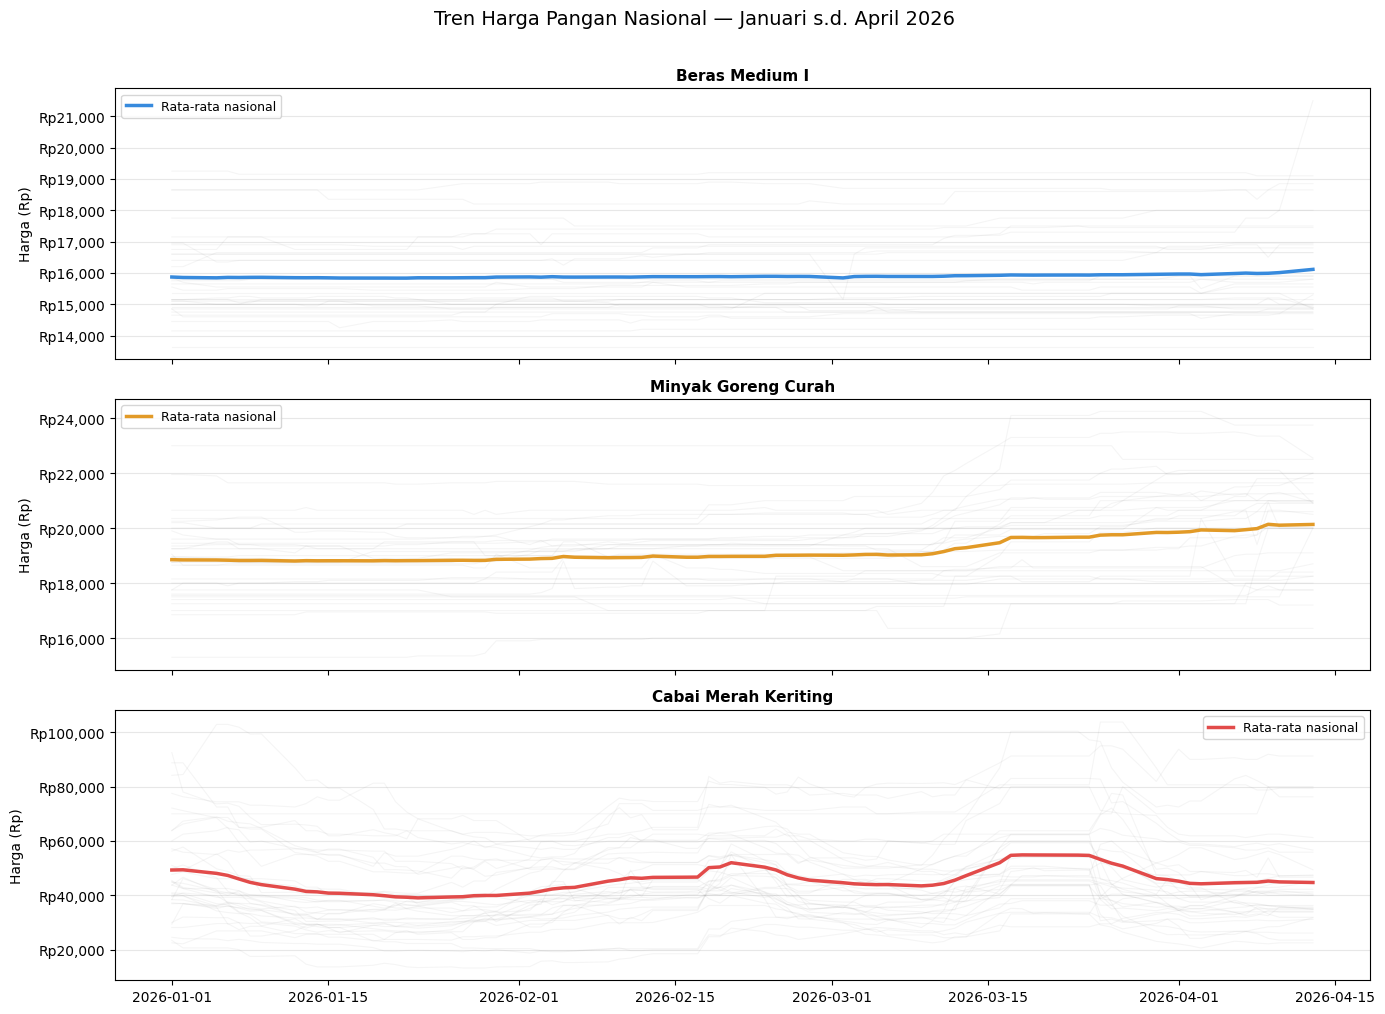

✅ Grafik tersimpan → data/predictions/tren_historis.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Tren Harga Pangan Nasional — Januari s.d. April 2026", fontsize=14, y=1.01)

warna = {
    "Beras Medium I"       : "#378ADD",
    "Minyak Goreng Curah"  : "#E29A27",
    "Cabai Merah Keriting" : "#E24B4A",
}

for ax, kom in zip(axes, KOMODITAS_LIST):
    # Rata-rata nasional per hari
    nasional = df[df['komoditas']==kom].groupby('tanggal')['harga'].mean()
    
    # Semua provinsi (transparan) sebagai background
    for prov in df['provinsi'].unique():
        sub = df[(df['komoditas']==kom) & (df['provinsi']==prov)]
        ax.plot(sub['tanggal'], sub['harga'], color='gray', alpha=0.08, linewidth=0.8)
    
    # Rata-rata nasional (tebal)
    ax.plot(nasional.index, nasional.values,
            color=warna[kom], linewidth=2.5, label='Rata-rata nasional')
    
    ax.set_ylabel("Harga (Rp)", fontsize=10)
    ax.set_title(kom, fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp{x:,.0f}"))
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(PRED_DIR / "chart" /"tren_historis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik tersimpan → data/predictions/tren_historis.png")


## 4. Fungsi Model Prophet

### Kenapa Prophet?
- Dirancang untuk data bisnis dengan pola musiman
- Robust terhadap outlier dan missing values  
- Tidak butuh data ratusan tahun — cocok untuk 73 hari data kita
- Output langsung dengan **confidence interval** (uncertainty band)
- Bisa memperhitungkan efek hari libur seperti Lebaran


In [8]:
def latih_dan_prediksi(df_input: pd.DataFrame,
                       provinsi: str,
                       komoditas: str,
                       horizon: int = HORIZON_HARI) -> dict | None:
    """
    Latih model Prophet untuk satu kombinasi provinsi × komoditas.
    
    Returns dict berisi:
    - Ringkasan prediksi 7 & 30 hari
    - Data prediksi harian (untuk grafik)
    - Metrik akurasi (MAE, MAPE)
    """
    
    # Format Prophet: kolom 'ds' (tanggal) dan 'y' (nilai)
    dp = (df_input[['tanggal', 'harga']]
          .rename(columns={'tanggal': 'ds', 'harga': 'y'})
          .drop_duplicates('ds')
          .sort_values('ds'))
    
    if len(dp) < 10:
        return None
    
    # Floor: prediksi tidak boleh turun di bawah 40% rata-rata historis
    # Ini mencegah prediksi negatif tanpa memakai logistic growth
    # yang tidak stabil di data pendek
    floor = dp['y'].mean() * FLOOR_RATIO
    
    # ── Inisialisasi & Training ───────────────────────────────────
    model = Prophet(
        yearly_seasonality      = False,   # Data hanya 3.5 bulan
        weekly_seasonality      = True,    # Ada pola hari dalam seminggu
        daily_seasonality       = False,
        holidays                = HARI_LIBUR,
        changepoint_prior_scale = CHANGEPOINT_SCALE,
        interval_width          = INTERVAL_WIDTH,
        seasonality_mode        = 'multiplicative',  # Lebih cocok untuk harga
    )
    
    # Tambah pola bulanan secara manual
    model.add_seasonality(name='monthly', period=30.5, fourier_order=3)
    model.fit(dp)
    
    # ── Prediksi ─────────────────────────────────────────────────
    # freq='B' = Business day (Senin-Jumat), sesuai jadwal update PIHPS
    future   = model.make_future_dataframe(periods=horizon, freq='B')
    forecast = model.predict(future)
    
    # Ambil prediksi masa depan saja
    terkini  = dp['ds'].max()
    pred_df  = forecast[forecast['ds'] > terkini].copy()
    
    # Clip agar tidak di bawah floor
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        pred_df[col] = pred_df[col].clip(lower=floor).round(0)
    
    # ── Hitung Akurasi pada Data Historis ────────────────────────
    hist      = forecast[forecast['ds'] <= terkini]['yhat'].values[:len(dp)]
    mae       = float(np.mean(np.abs(dp['y'].values - hist)))
    mape      = float(np.mean(np.abs((dp['y'].values - hist) / dp['y'].values)) * 100)
    
    # ── Ringkasan ─────────────────────────────────────────────────
    h_skrg   = float(dp['y'].iloc[-1])
    h_7      = float(pred_df['yhat'].iloc[6])  if len(pred_df) > 6  else h_skrg
    h_30     = float(pred_df['yhat'].iloc[-1]) if len(pred_df) > 0  else h_skrg
    
    def tren(a, b):
        pct = (a - b) / b * 100
        if pct > 5:   return 'NAIK'
        if pct < -5:  return 'TURUN'
        return 'STABIL'
    
    return {
        # Identitas
        'provinsi'        : provinsi,
        'komoditas'       : komoditas,
        'tanggal_data'    : str(terkini.date()),
        
        # Harga & prediksi
        'harga_sekarang'  : round(h_skrg, 0),
        'prediksi_7h'     : round(h_7, 0),
        'bawah_7h'        : round(float(pred_df['yhat_lower'].iloc[6]), 0) if len(pred_df) > 6 else None,
        'atas_7h'         : round(float(pred_df['yhat_upper'].iloc[6]), 0) if len(pred_df) > 6 else None,
        'tren_7h'         : tren(h_7, h_skrg),
        
        'prediksi_30h'    : round(h_30, 0),
        'bawah_30h'       : round(float(pred_df['yhat_lower'].iloc[-1]), 0),
        'atas_30h'        : round(float(pred_df['yhat_upper'].iloc[-1]), 0),
        'tren_30h'        : tren(h_30, h_skrg),
        
        # Akurasi
        'mae'             : round(mae, 0),
        'mape_pct'        : round(mape, 2),
        
        # Data harian untuk grafik (pisah dari ringkasan)
        '_prediksi_harian': pred_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(
            columns={'ds': 'tanggal', 'yhat': 'prediksi',
                     'yhat_lower': 'batas_bawah', 'yhat_upper': 'batas_atas'}
        ).assign(
            tanggal    = lambda x: x['tanggal'].dt.date.astype(str),
            provinsi   = provinsi,
            komoditas  = komoditas,
        ),
        
        # Simpan model untuk visualisasi
        '_model'    : model,
        '_forecast' : forecast,
        '_dp'       : dp,
    }

print("✅ Fungsi latih_dan_prediksi() siap")


✅ Fungsi latih_dan_prediksi() siap


## 5. Jalankan Model — Semua Komoditas × Semua Provinsi

In [9]:
semua_hasil      = []
semua_prediksi   = []
gagal            = []

provinsi_list = df['provinsi'].unique()
total         = len(KOMODITAS_LIST) * len(provinsi_list)
selesai       = 0

print(f"Total kombinasi: {total} (komoditas × provinsi)")
print("=" * 60)

for kom in KOMODITAS_LIST:
    print(f"\n▶ {kom}")
    hasil_kom = []
    
    for prov in provinsi_list:
        mask = (df['komoditas'] == kom) & (df['provinsi'] == prov)
        sub  = df[mask].copy()
        
        try:
            hasil = latih_dan_prediksi(sub, prov, kom)
            if hasil:
                # Pisahkan prediksi harian sebelum simpan ke list ringkasan
                pred_harian = hasil.pop('_prediksi_harian')
                hasil.pop('_model')
                hasil.pop('_forecast')
                hasil.pop('_dp')
                
                semua_hasil.append(hasil)
                hasil_kom.append(hasil)
                semua_prediksi.append(pred_harian)
                
        except Exception as e:
            gagal.append({'komoditas': kom, 'provinsi': prov, 'error': str(e)})
        
        selesai += 1
    
    # Ringkasan per komoditas
    df_kom = pd.DataFrame(hasil_kom)
    print(f"  Selesai   : {len(hasil_kom)} provinsi")
    print(f"  MAPE avg  : {df_kom['mape_pct'].mean():.2f}%")
    print(f"  Tren 30h  : NAIK={( df_kom['tren_30h']=='NAIK').sum()}  "
          f"TURUN={( df_kom['tren_30h']=='TURUN').sum()}  "
          f"STABIL={( df_kom['tren_30h']=='STABIL').sum()}")

print(f"\n{'='*60}")
print(f"✅ Selesai! {len(semua_hasil)} model berhasil, {len(gagal)} gagal")


Total kombinasi: 99 (komoditas × provinsi)

▶ Beras Medium I


21:10:01 - cmdstanpy - INFO - Chain [1] start processing
21:10:11 - cmdstanpy - INFO - Chain [1] done processing
21:10:11 - cmdstanpy - INFO - Chain [1] start processing
21:10:17 - cmdstanpy - INFO - Chain [1] done processing
21:10:18 - cmdstanpy - INFO - Chain [1] start processing
21:10:24 - cmdstanpy - INFO - Chain [1] done processing
21:10:25 - cmdstanpy - INFO - Chain [1] start processing
21:10:25 - cmdstanpy - INFO - Chain [1] done processing
21:10:26 - cmdstanpy - INFO - Chain [1] start processing
21:10:31 - cmdstanpy - INFO - Chain [1] done processing
21:10:31 - cmdstanpy - INFO - Chain [1] start processing
21:10:39 - cmdstanpy - INFO - Chain [1] done processing
21:10:39 - cmdstanpy - INFO - Chain [1] start processing
21:10:43 - cmdstanpy - INFO - Chain [1] done processing
21:10:44 - cmdstanpy - INFO - Chain [1] start processing
21:10:50 - cmdstanpy - INFO - Chain [1] done processing
21:10:50 - cmdstanpy - INFO - Chain [1] start processing
21:10:55 - cmdstanpy - INFO - Chain [1]

  Selesai   : 33 provinsi
  MAPE avg  : 0.07%
  Tren 30h  : NAIK=4  TURUN=2  STABIL=27

▶ Minyak Goreng Curah


21:13:59 - cmdstanpy - INFO - Chain [1] done processing
21:13:59 - cmdstanpy - INFO - Chain [1] start processing
21:14:02 - cmdstanpy - INFO - Chain [1] done processing
21:14:03 - cmdstanpy - INFO - Chain [1] start processing
21:14:06 - cmdstanpy - INFO - Chain [1] done processing
21:14:06 - cmdstanpy - INFO - Chain [1] start processing
21:14:13 - cmdstanpy - INFO - Chain [1] done processing
21:14:13 - cmdstanpy - INFO - Chain [1] start processing
21:14:17 - cmdstanpy - INFO - Chain [1] done processing
21:14:17 - cmdstanpy - INFO - Chain [1] start processing
21:14:20 - cmdstanpy - INFO - Chain [1] done processing
21:14:20 - cmdstanpy - INFO - Chain [1] start processing
21:14:24 - cmdstanpy - INFO - Chain [1] done processing
21:14:24 - cmdstanpy - INFO - Chain [1] start processing
21:14:29 - cmdstanpy - INFO - Chain [1] done processing
21:14:29 - cmdstanpy - INFO - Chain [1] start processing
21:14:32 - cmdstanpy - INFO - Chain [1] done processing
21:14:32 - cmdstanpy - INFO - Chain [1] 

  Selesai   : 31 provinsi
  MAPE avg  : 0.16%
  Tren 30h  : NAIK=6  TURUN=4  STABIL=21

▶ Cabai Merah Keriting


21:16:10 - cmdstanpy - INFO - Chain [1] done processing
21:16:11 - cmdstanpy - INFO - Chain [1] start processing
21:16:12 - cmdstanpy - INFO - Chain [1] done processing
21:16:12 - cmdstanpy - INFO - Chain [1] start processing
21:16:13 - cmdstanpy - INFO - Chain [1] done processing
21:16:14 - cmdstanpy - INFO - Chain [1] start processing
21:16:15 - cmdstanpy - INFO - Chain [1] done processing
21:16:15 - cmdstanpy - INFO - Chain [1] start processing
21:16:16 - cmdstanpy - INFO - Chain [1] done processing
21:16:16 - cmdstanpy - INFO - Chain [1] start processing
21:16:18 - cmdstanpy - INFO - Chain [1] done processing
21:16:18 - cmdstanpy - INFO - Chain [1] start processing
21:16:18 - cmdstanpy - INFO - Chain [1] done processing
21:16:19 - cmdstanpy - INFO - Chain [1] start processing
21:16:20 - cmdstanpy - INFO - Chain [1] done processing
21:16:20 - cmdstanpy - INFO - Chain [1] start processing
21:16:21 - cmdstanpy - INFO - Chain [1] done processing
21:16:21 - cmdstanpy - INFO - Chain [1] 

  Selesai   : 33 provinsi
  MAPE avg  : 2.28%
  Tren 30h  : NAIK=9  TURUN=23  STABIL=1

✅ Selesai! 97 model berhasil, 0 gagal


## 6. Simpan Hasil

In [10]:
# Ringkasan prediksi semua provinsi × komoditas
df_hasil = pd.DataFrame(semua_hasil)
df_hasil.to_csv(PRED_DIR / "csv" /"hasil_prediksi.csv", index=False)
print(f"✅ Ringkasan prediksi → {PRED_DIR / 'hasil_prediksi.csv'}")
print(f"   Shape: {df_hasil.shape}")

# Data prediksi harian (untuk grafik di dashboard)
df_harian = pd.concat(semua_prediksi, ignore_index=True)
df_harian.to_csv(PRED_DIR / "csv" /"prediksi_harian.csv", index=False)
print(f"✅ Prediksi harian   → {PRED_DIR / 'prediksi_harian.csv'}")
print(f"   Shape: {df_harian.shape}")

# Alert JSON — provinsi yang diprediksi naik signifikan
df_alert = df_hasil[df_hasil['tren_30h'] == 'NAIK'].copy()
df_alert['kenaikan_pct'] = (
    (df_alert['prediksi_30h'] - df_alert['harga_sekarang'])
    / df_alert['harga_sekarang'] * 100
).round(1)
df_alert = df_alert.sort_values('kenaikan_pct', ascending=False)

alert_json = df_alert[
    ['komoditas','provinsi','harga_sekarang','prediksi_30h','kenaikan_pct','tren_7h']
].to_dict(orient='records')

with open(PRED_DIR / "json" /"alert_prediksi.json", 'w', encoding='utf-8') as f:
    json.dump(alert_json, f, ensure_ascii=False, indent=2)
print(f"✅ Alert JSON        → {PRED_DIR / 'alert_prediksi.json'}")
print(f"   {len(df_alert)} provinsi masuk kategori ALERT NAIK")


✅ Ringkasan prediksi → data\predictions\hasil_prediksi.csv
   Shape: (97, 14)
✅ Prediksi harian   → data\predictions\prediksi_harian.csv
   Shape: (2910, 6)
✅ Alert JSON        → data\predictions\alert_prediksi.json
   19 provinsi masuk kategori ALERT NAIK


## 7. Evaluasi Akurasi Model

In [11]:
print("=== AKURASI MODEL PER KOMODITAS ===\n")

for kom in KOMODITAS_LIST:
    sub = df_hasil[df_hasil['komoditas'] == kom]
    print(f"{kom}")
    print(f"  MAPE rata-rata : {sub['mape_pct'].mean():.2f}%")
    print(f"  MAE rata-rata  : Rp {sub['mae'].mean():,.0f}")
    print(f"  MAPE terbaik   : {sub['mape_pct'].min():.2f}% ({sub.loc[sub['mape_pct'].idxmin(), 'provinsi']})")
    print(f"  MAPE terburuk  : {sub['mape_pct'].max():.2f}% ({sub.loc[sub['mape_pct'].idxmax(), 'provinsi']})")
    print()

print("─" * 40)
print("Interpretasi MAPE:")
print("  < 10%  = Sangat Akurat ✅")
print("  10-20% = Cukup Akurat  ⚠️")
print("  > 20%  = Perlu perbaikan ❌")


=== AKURASI MODEL PER KOMODITAS ===

Beras Medium I
  MAPE rata-rata : 0.07%
  MAE rata-rata  : Rp 11
  MAPE terbaik   : 0.00% (Bengkulu)
  MAPE terburuk  : 0.46% (DKI Jakarta)

Minyak Goreng Curah
  MAPE rata-rata : 0.16%
  MAE rata-rata  : Rp 31
  MAPE terbaik   : 0.04% (Papua)
  MAPE terburuk  : 0.59% (Kepulauan Riau)

Cabai Merah Keriting
  MAPE rata-rata : 2.28%
  MAE rata-rata  : Rp 955
  MAPE terbaik   : 0.65% (Jawa Tengah)
  MAPE terburuk  : 11.83% (Gorontalo)

────────────────────────────────────────
Interpretasi MAPE:
  < 10%  = Sangat Akurat ✅
  10-20% = Cukup Akurat  ⚠️
  > 20%  = Perlu perbaikan ❌


## 8. Visualisasi Prediksi — Contoh per Komoditas

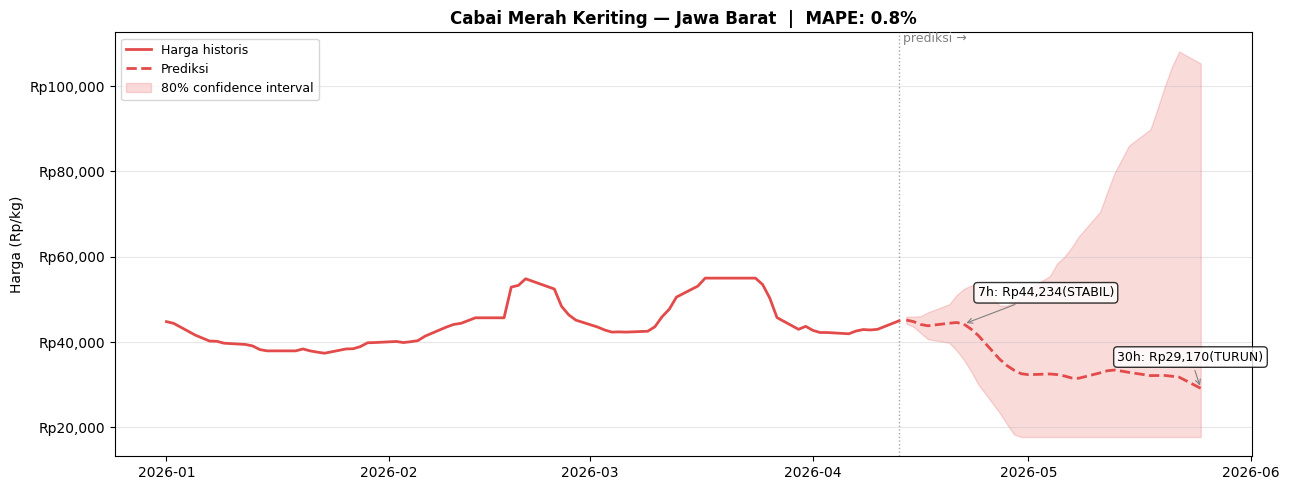

✅ Tersimpan → prediksi_Jawa_Barat_Cabai_Merah_Keriting.png


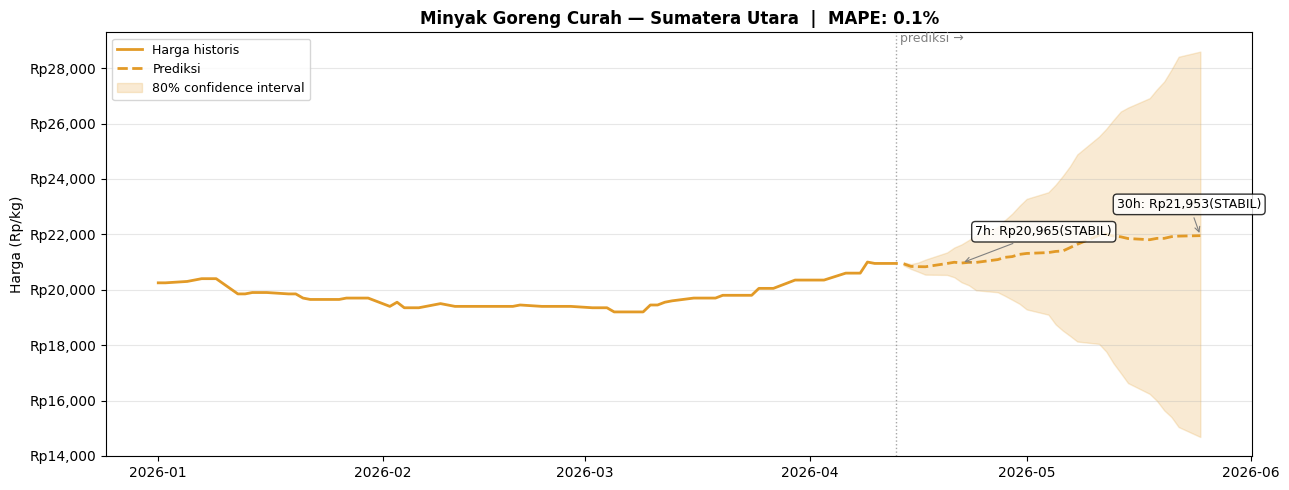

✅ Tersimpan → prediksi_Sumatera_Utara_Minyak_Goreng_Curah.png


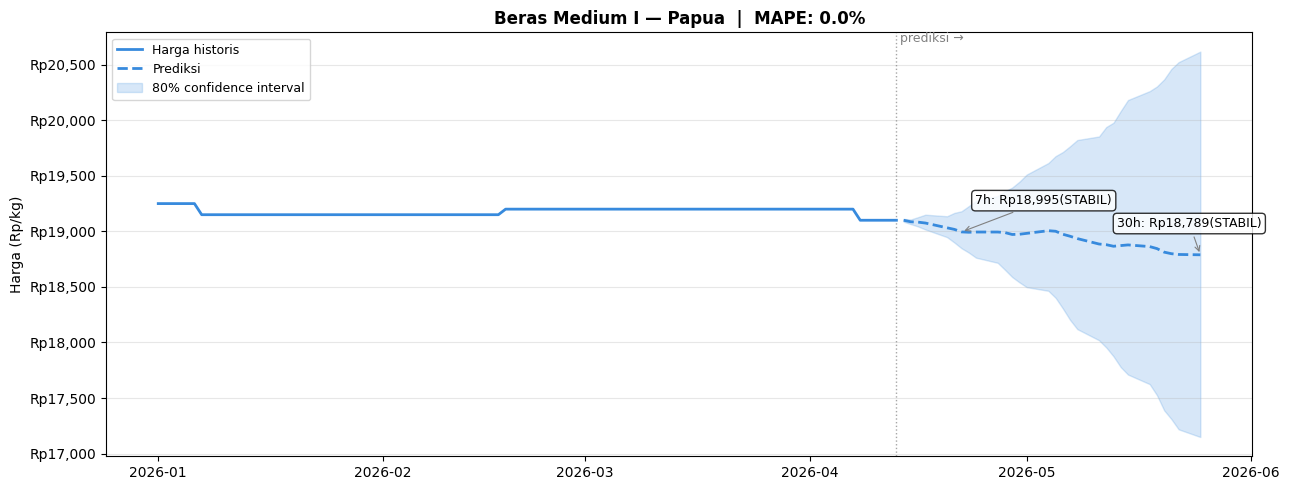

✅ Tersimpan → prediksi_Papua_Beras_Medium_I.png


In [12]:
def plot_prediksi(provinsi_target: str, komoditas_target: str):
    """Plot historis + prediksi dengan confidence interval untuk satu provinsi."""
    
    # Ambil data historis
    mask = (df['komoditas'] == komoditas_target) & (df['provinsi'] == provinsi_target)
    hist = df[mask].sort_values('tanggal')
    
    # Ambil prediksi harian
    mask2 = (df_harian['komoditas'] == komoditas_target) & (df_harian['provinsi'] == provinsi_target)
    pred  = df_harian[mask2].copy()
    pred['tanggal'] = pd.to_datetime(pred['tanggal'])
    
    if hist.empty or pred.empty:
        print(f"Data tidak ditemukan untuk {provinsi_target} - {komoditas_target}")
        return
    
    # Ambil ringkasan
    ring = df_hasil[
        (df_hasil['komoditas'] == komoditas_target) &
        (df_hasil['provinsi']  == provinsi_target)
    ].iloc[0]
    
    warna_kom = {
        "Beras Medium I"       : "#378ADD",
        "Minyak Goreng Curah"  : "#E29A27",
        "Cabai Merah Keriting" : "#E24B4A",
    }
    warna = warna_kom.get(komoditas_target, "#378ADD")
    
    fig, ax = plt.subplots(figsize=(13, 5))
    
    # Garis historis
    ax.plot(hist['tanggal'], hist['harga'],
            color=warna, linewidth=2, label='Harga historis', zorder=3)
    
    # Garis prediksi (putus-putus)
    ax.plot(pred['tanggal'], pred['prediksi'],
            color=warna, linewidth=2, linestyle='--', label='Prediksi', zorder=3)
    
    # Confidence interval (area abu-abu)
    ax.fill_between(pred['tanggal'], pred['batas_bawah'], pred['batas_atas'],
                    alpha=0.2, color=warna, label='80% confidence interval')
    
    # Garis vertikal pemisah historis vs prediksi
    tgl_terakhir = hist['tanggal'].max()
    ax.axvline(tgl_terakhir, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    ax.text(tgl_terakhir, ax.get_ylim()[1], ' prediksi →',
            fontsize=9, color='gray', va='top')
    
    # Anotasi prediksi 7 & 30 hari
    tgl_7  = pred['tanggal'].iloc[6]  if len(pred) > 6  else pred['tanggal'].iloc[-1]
    tgl_30 = pred['tanggal'].iloc[-1]
    h7     = ring['prediksi_7h']
    h30    = ring['prediksi_30h']
    
    ax.annotate(f"7h: Rp{h7:,.0f}({ring['tren_7h']})",
                xy=(tgl_7, h7), xytext=(10, 20),
                textcoords='offset points', fontsize=9,
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    ax.annotate(f"30h: Rp{h30:,.0f}({ring['tren_30h']})",
                xy=(tgl_30, h30), xytext=(-60, 20),
                textcoords='offset points', fontsize=9,
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    ax.set_title(f"{komoditas_target} — {provinsi_target}  |  MAPE: {ring['mape_pct']:.1f}%",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel("Harga (Rp/kg)", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp{x:,.0f}"))
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    
    fname = f"prediksi_{provinsi_target.replace(' ','_')}_{komoditas_target.replace(' ','_')}.png"
    plt.savefig(PRED_DIR / "chart" /fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Tersimpan → {fname}")

# ── Jalankan untuk beberapa contoh ───────────────────────────────
plot_prediksi("Jawa Barat",        "Cabai Merah Keriting")
plot_prediksi("Sumatera Utara",    "Minyak Goreng Curah")
plot_prediksi("Papua",             "Beras Medium I")


## 9. Heatmap Alert — Provinsi Mana yang Perlu Diwaspadai?

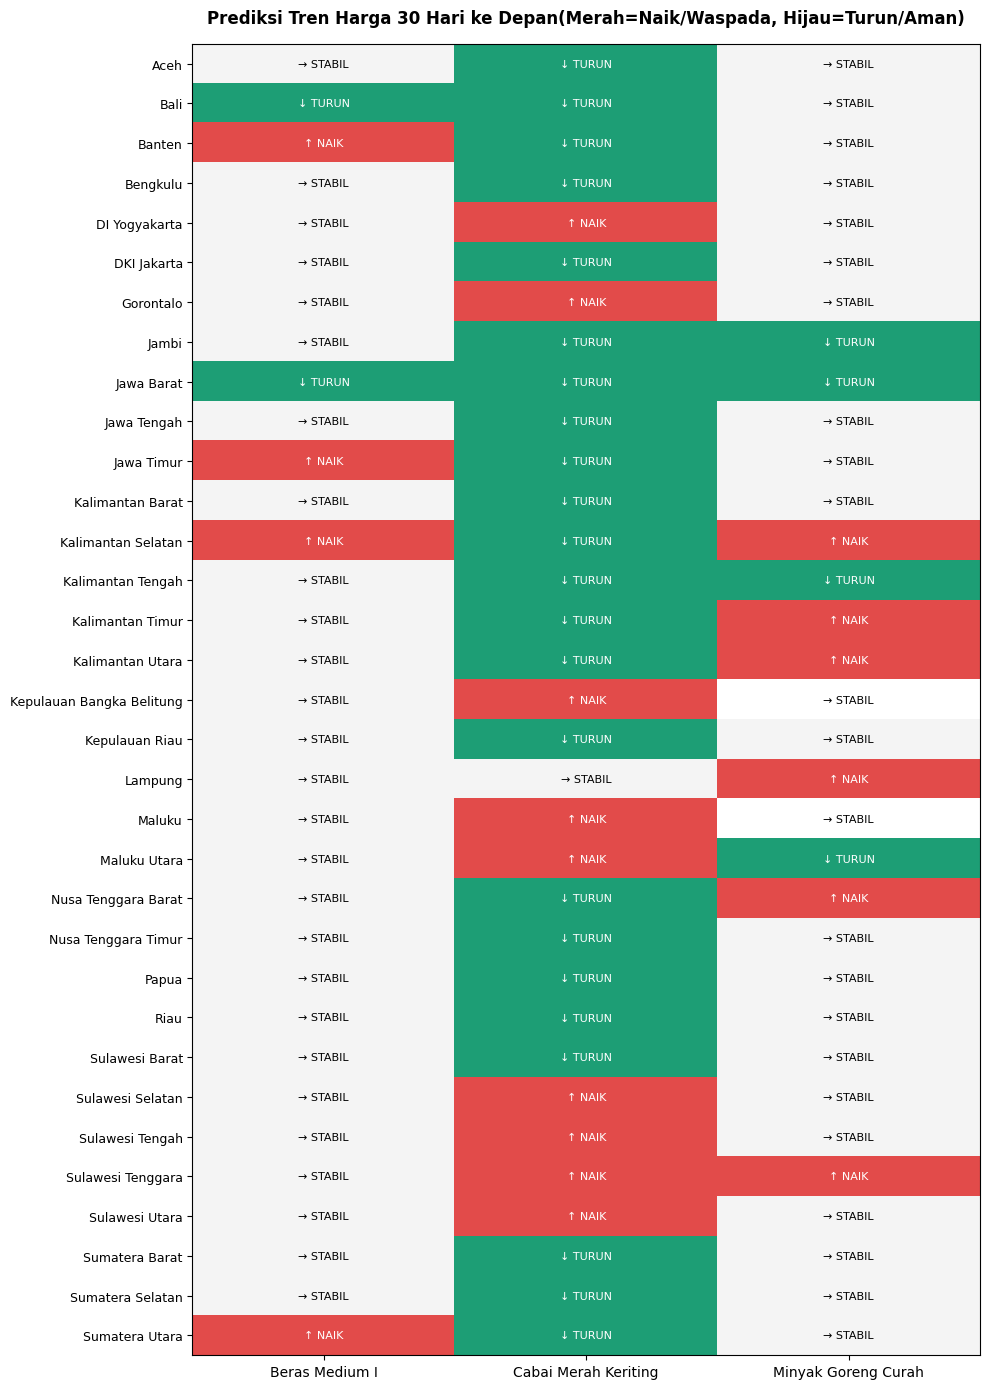

✅ Heatmap tersimpan → data/predictions/heatmap_alert.png


In [13]:
import matplotlib.colors as mcolors

# Buat pivot: provinsi × komoditas, nilai = tren_30h
tren_map = {'NAIK': 1, 'STABIL': 0, 'TURUN': -1}
df_pivot = df_hasil.copy()
df_pivot['tren_num'] = df_pivot['tren_30h'].map(tren_map)
pivot = df_pivot.pivot_table(index='provinsi', columns='komoditas',
                              values='tren_num', aggfunc='first')

fig, ax = plt.subplots(figsize=(10, 14))
cmap = mcolors.LinearSegmentedColormap.from_list(
    'traffic', ['#1D9E75', '#F5F5F5', '#E24B4A'])

im = ax.imshow(pivot.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

# Label
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Teks di tiap sel
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        label = {1: '↑ NAIK', 0: '→ STABIL', -1: '↓ TURUN'}.get(int(val) if not np.isnan(val) else 0, '-')
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, label, ha='center', va='center', fontsize=8, color=color)

ax.set_title("Prediksi Tren Harga 30 Hari ke Depan(Merah=Naik/Waspada, Hijau=Turun/Aman)",
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(PRED_DIR / "heatmap_alert.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap tersimpan → data/predictions/heatmap_alert.png")


## 10. Ringkasan Akhir & Langkah Berikutnya

In [14]:
print("=" * 60)
print("  RINGKASAN MODEL PREDIKSI")
print("=" * 60)
print(f"\nTotal model terlatih  : {len(df_hasil)}")
print(f"MAPE rata-rata global : {df_hasil['mape_pct'].mean():.2f}%")
print(f"MAE rata-rata global  : Rp {df_hasil['mae'].mean():,.0f}")

print("\n─── Output Files ───")
for f in sorted(PRED_DIR.glob("*")):
    size = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size:>6.1f} KB")

print("\n─── Alert Provinsi NAIK 30 Hari (Top 5) ───")
top5 = df_alert.head(5)[['komoditas','provinsi','harga_sekarang','prediksi_30h','kenaikan_pct']]
for _, r in top5.iterrows():
    print(f"  {r['komoditas']:<25} {r['provinsi']:<20} "
          f"Rp{r['harga_sekarang']:>8,.0f} → Rp{r['prediksi_30h']:>8,.0f} "
          f"(+{r['kenaikan_pct']:.1f}%)")

print("\n─── Langkah Berikutnya ───")
print("  1. Engine Rekomendasi → dari prediksi jadi saran aksi")
print("  2. Integrasi Azure AI Language → analisis berita pangan")
print("  3. Build Dashboard Web (Streamlit / React)")
print("  4. Deploy ke Azure Static Web Apps")


  RINGKASAN MODEL PREDIKSI

Total model terlatih  : 97
MAPE rata-rata global : 0.85%
MAE rata-rata global  : Rp 338

─── Output Files ───
  chart                                       4.0 KB
  csv                                         0.0 KB
  heatmap_alert.png                         179.3 KB
  json                                        0.0 KB

─── Alert Provinsi NAIK 30 Hari (Top 5) ───
  Beras Medium I            Kalimantan Selatan   Rp  21,500 → Rp  35,129 (+63.4%)
  Cabai Merah Keriting      Sulawesi Selatan     Rp  31,750 → Rp  48,573 (+53.0%)
  Minyak Goreng Curah       Kalimantan Selatan   Rp  20,000 → Rp  28,755 (+43.8%)
  Cabai Merah Keriting      Gorontalo            Rp  49,400 → Rp  70,316 (+42.3%)
  Cabai Merah Keriting      Maluku               Rp  91,250 → Rp 126,518 (+38.6%)

─── Langkah Berikutnya ───
  1. Engine Rekomendasi → dari prediksi jadi saran aksi
  2. Integrasi Azure AI Language → analisis berita pangan
  3. Build Dashboard Web (Streamlit / React)
  4. Dep